# Precomputed XGBoost Forward Return

Load precomputed LOB features and forward-return labels from `data/orderbook_feature_return_parquet`, infer the feature set from the parquet schema, then run rolling time-series validation with the streaming `XGBoostAdapter`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import re
import sys
from pathlib import Path

import numpy as np
import polars as pl
from matplotlib import pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from tools.data import DataSource, DateFrame, Raw, expand_dates
from tools.filters import intraday_time, level_taken, tight_spread, trade_size
from tools.model import XGBoostAdapter
from tools.pipeline import Pipeline
from tools.score import get_pinball, get_quantile_pnl, get_unit_pnl, rmse
from tools.search import categorical, int_, loguniform, uniform, grid

In [3]:
def divide_dates(*args):
    dates = []
    for i in range(1, len(args)):
        dates.append(
            expand_dates(
                f"{args[i - 1]}-{args[i]}",
                end_date=False if i < len(args) - 1 else True,
            )
        )
    return dates

In [4]:
# Data
PROD = "ES"
ROLLING_DATES = divide_dates(20260323, 20260410, 20260425, 20260510, 20260524)
TEST_DATES = expand_dates("20260525-20260529")
L2_DEPTH = 5
MODEL_BATCH_SIZE = 200_000
POLARS_ENGINE = "streaming"
FEATURE_RETURN_PATH = str(
    ROOT
    / f"data/orderbook_feature_return_parquet/{{prod}}M6_{{d}}_{{tag}}_{{prod_s}}_full_day_l2_d{L2_DEPTH}_features_return.parquet"
)
REGULAR_HOURS_START = "09:30"
REGULAR_HOURS_END = "16:00"
REGULAR_HOURS_TZ = "America/New_York"

# Forward-return target column already present in FEATURE_RETURN_PATH files.
TARGET = "forward_mid_return_bps"
TEST_PNL_THRESHOLD = 0.2

# XGBoost/search knobs
SEED = 7
SAMPLER = "random"
N_TRIALS = 20
NUM_BOOST_ROUND = 500
EARLY_STOPPING_ROUNDS = 10
QUANTILES = [0.1, 0.5, 0.9]  # adapter sets objective=reg:quantileerror + quantile_alpha
MEDIAN_IDX = QUANTILES.index(0.5)
SEARCH_SPACE = {
    "eval_metric": categorical(["quantile"]),
    "tree_method": categorical(["hist"]),
    "device": categorical(["cuda"]),
    "seed": categorical([SEED]),
    "max_depth": int_(2, 6),
    "eta": grid([0.01]),
    "subsample": uniform(0.6, 1.0),
    "colsample_bytree": uniform(0.5, 1.0),
    "min_child_weight": loguniform(1.0, 100.0),
    "lambda": loguniform(1e-3, 100.0),
    "alpha": loguniform(1e-4, 10.0),
}


def median_quantile(score):
    # Multi-quantile predict() returns (n, len(QUANTILES)); score point metrics on the median column.
    def wrapped(y_true, y_pred, ctx=None, **kwargs):
        y_pred = np.asarray(y_pred)
        if y_pred.ndim == 2:
            y_pred = y_pred[:, MEDIAN_IDX]
        return score(y_true, y_pred, ctx, **kwargs)

    wrapped.__name__ = f"median_{getattr(score, '__name__', 'score')}"
    return wrapped


UNDEF_PRICE = 9_223_372_036_854_775_807
TICKSIZE = 250000000

In [5]:
BOOK_COL_RE = re.compile(r"^(?:bid|ask)_(?:px|sz|ct)_\d+$")
SCHEMA_NON_FEATURE_COLS = {
    "date",
    "nature",
    "ts_event",
    "ts_recv",
    "symbol",
    "instrument_id",
    "row_nr",
    "sequence",
    "publisher_id",
    "trade_px",
    "trade_sz",
    "trade_side",
}

def infer_features_from_schema(schema: pl.Schema, target: str = TARGET) -> list[str]:
    features = []
    for col in schema.names():
        if col == target or col in SCHEMA_NON_FEATURE_COLS or BOOK_COL_RE.match(col):
            continue
        features.append(col)
    if not features:
        raise ValueError("no feature columns inferred from parquet schema")
    return features

FEATURE_SCHEMA_PATH, _ = Raw.resolve_path(ROLLING_DATES[0][0], PROD, FEATURE_RETURN_PATH)
FEATURE_SCHEMA = pl.scan_parquet(FEATURE_SCHEMA_PATH).collect_schema()
FEATURES = infer_features_from_schema(FEATURE_SCHEMA)
# FEATURES = ['weighted_price_sz2']
META_COLS = [col for col in FEATURE_SCHEMA.names() if col not in FEATURES and col != TARGET]
LOAD_COLS = list(dict.fromkeys([*META_COLS, *FEATURES, TARGET]))

FEATURES

['imb_d1',
 'imb_d3',
 'imb_d5',
 'weighted_price_sz2',
 'weighted_price_sz5',
 'weighted_price_sz10',
 'trade_momentum_hl1s',
 'trade_momentum_hl10s',
 'trade_momentum_hl30s',
 'trade_momentum_hl120s']

In [6]:
VALID_ROWS = (
    (pl.col("bid_px_0") != UNDEF_PRICE)
    & (pl.col("ask_px_0") != UNDEF_PRICE)
    & (pl.col("ask_px_0") > pl.col("bid_px_0"))
    & pl.col(TARGET).is_not_null()
    & pl.all_horizontal([pl.col(c).is_finite() for c in FEATURES])
)
REGULAR_HOURS = intraday_time(REGULAR_HOURS_START, REGULAR_HOURS_END, timezone=REGULAR_HOURS_TZ)
TIGHT_SPREAD = tight_spread(TICKSIZE)
VALID_REGULAR_ROWS = VALID_ROWS & REGULAR_HOURS & TIGHT_SPREAD
TRAIN_ROWS = VALID_REGULAR_ROWS & (level_taken() | trade_size(0.3))

REGULAR_HOURS

<Expr ['[([(col("ts_event").dt.convert…'] at 0x7CD6695F7650>

In [7]:
def load_feature_return_date(day: str, prod: str = PROD) -> DateFrame:
    return Raw.load_date(day, prod, path=FEATURE_RETURN_PATH, cols=LOAD_COLS)


def regular_loader(dates: list[str]) -> list[DateFrame]:
    return [load_feature_return_date(day) for day in dates]

In [8]:
FEATURE_TEST_SCORE = get_unit_pnl(TEST_PNL_THRESHOLD)
FEATURE_TEST_SCORE_DESCENDING = True

test_date_src = DataSource(
    dates=TEST_DATES,
    loader=regular_loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)

feature_test_states = dict.fromkeys(FEATURES)
feature_test_rows = 0
for x, y_true, ctx in test_date_src.batches(MODEL_BATCH_SIZE):
    feature_test_rows += int(ctx["n"])
    for idx, feature in enumerate(FEATURES):
        feature_test_states[feature] = FEATURE_TEST_SCORE(
            y_true,
            x[:, idx],
            ctx,
            combine_with=feature_test_states[feature],
        )

feature_test_scores = (
    pl.DataFrame(
        [
            {
                "feature": feature,
                "score": getattr(FEATURE_TEST_SCORE, "__name__", "score"),
                "test_score": float(state),
                "score_n": int(getattr(state, "n", 0)),
                "rows": feature_test_rows,
            }
            for feature, state in feature_test_states.items()
            if state is not None
        ]
    )
    .sort("test_score", descending=FEATURE_TEST_SCORE_DESCENDING)
)

feature_test_scores

Loading data: 25.6Mrow [00:08, 3.05Mrow/s]


feature,score,test_score,score_n,rows
str,str,f64,i64,i64
"""weighted_price_sz2""","""unit_pnl_0.2""",0.334344,450,25573459
"""imb_d5""","""unit_pnl_0.2""",0.11094,19635053,25573459
"""imb_d3""","""unit_pnl_0.2""",0.107287,20884077,25573459
"""imb_d1""","""unit_pnl_0.2""",0.102078,23090022,25573459
"""trade_momentum_hl120s""","""unit_pnl_0.2""",0.01818,10962617,25573459
"""trade_momentum_hl1s""","""unit_pnl_0.2""",0.001741,22547259,25573459
"""trade_momentum_hl10s""","""unit_pnl_0.2""",0.001076,19066148,25573459
"""trade_momentum_hl30s""","""unit_pnl_0.2""",-0.020918,15956186,25573459
"""weighted_price_sz5""","""unit_pnl_0.2""",-0.1691,2618,25573459


CV folds can early-stop because they have validation data and record their best rounds. `train(..., no_refit=True)` skips final training; the notebook then refits explicitly with the max CV best round, capped by `NUM_BOOST_ROUND`.

In [9]:
pipeline = Pipeline(
    rolling_dates=ROLLING_DATES,
    test_dates=TEST_DATES,
    adapter=XGBoostAdapter(
        num_boost_round=NUM_BOOST_ROUND,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        batch_size=MODEL_BATCH_SIZE,
        streaming=True,
        quantiles=QUANTILES,
        pruning_metric="val-quantile",
    ),
    target=TARGET,
    features=FEATURES,
    data_loader=regular_loader,
    search_space=SEARCH_SPACE,
    val_score=get_pinball(QUANTILES),
    train_filters=(TRAIN_ROWS,),
    val_filters=(TRAIN_ROWS,),
    test_filters=(VALID_REGULAR_ROWS,),
    sampler=SAMPLER,
    n_trials=N_TRIALS,
    cache_arrays=False,
    seed=SEED,
    score_direction="minimize",
    polars_engine=POLARS_ENGINE,
)
pipeline

Pipeline(rolling_dates=[['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'], ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24'], ['2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08'], ['2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22']], test_dates=['2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29'], adapter=XGBoostAdapter(num_boost_round=100, early_stopping_rounds=10, batch_size=200000, streaming=True, external_memory=False, cache_dir='/tmp/xgb_extmem', cache_prefix='xgb', release_data=True, xgb_dtype=<class 'numpy.float32'>, callbacks=[], pruning_metric='val-quantile', quanti

In [10]:
ROLLING_DATES[-1][:1]

['2026-05-11']

In [11]:
src = DataSource(
    dates=ROLLING_DATES[-1][-1:],
    loader=regular_loader,
    target=TARGET,
    features=FEATURES + ["ts_event", "bid_px_0", "ask_px_0"],
    filters=(VALID_ROWS,),
    polars_engine=POLARS_ENGINE,
)

df = src.frame()[::1000].collect(engine=POLARS_ENGINE)
sprd = 2.0 * (pl.col("ask_px_0") - pl.col("bid_px_0")) / (pl.col("ask_px_0") + pl.col("bid_px_0")) * 1e4
print(src.frame().select(sprd).min().collect(engine=POLARS_ENGINE))
df.head()

shape: (1, 1)
┌──────────┐
│ literal  │
│ ---      │
│ f64      │
╞══════════╡
│ 0.332276 │
└──────────┘


imb_d1,imb_d3,imb_d5,weighted_price_sz2,weighted_price_sz5,weighted_price_sz10,trade_momentum_hl1s,trade_momentum_hl10s,trade_momentum_hl30s,trade_momentum_hl120s,ts_event,bid_px_0,ask_px_0,forward_mid_return_bps,date,nature
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,"datetime[ns, UTC]",i64,i64,f64,str,str
1.321756,1.38394,1.709186,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-05-17 12:00:04.934361375 UTC,7354000000000,7488000000000,0.0,"""2026-05-22""","""normal"""
-1.925291,-1.040901,-0.929928,0.0,0.0,-0.050154,0.0,0.0,0.0,0.0,2026-05-21 22:03:07.706784895 UTC,7470000000000,7484000000000,0.0,"""2026-05-22""","""normal"""
-2.70805,-1.026416,-0.755532,-0.083555,-0.133688,-0.1504,-0.046203,0.039892,0.046194,0.048555,2026-05-22 00:00:00.607721795 UTC,7480000000000,7480250000000,-1.721228,"""2026-05-22""","""normal"""
-1.94591,-0.684337,-0.538844,0.0,-0.100273,-0.133697,-1.703334,-0.375249,-0.241326,-0.189805,2026-05-22 00:00:09.032353093 UTC,7479500000000,7479750000000,-1.587646,"""2026-05-22""","""normal"""
-0.606136,-0.269031,-0.162035,0.0,0.0,-0.066846,-6.37595,-2.157476,-1.803333,-1.665656,2026-05-22 00:00:26.383719127 UTC,7479750000000,7480000000000,-3.693244,"""2026-05-22""","""normal"""


[[ 1.00000000e+00  9.31005425e-01  9.05178421e-01  5.59173899e-01
   7.95615314e-01  8.98898821e-01 -3.47488892e-03  1.70635301e-03
  -3.20642869e-04 -8.91589966e-03]
 [ 9.31005425e-01  1.00000000e+00  9.86065170e-01  4.19838900e-01
   6.54082999e-01  8.04982599e-01 -3.05997549e-02 -1.37151795e-02
  -1.05999151e-02 -1.55450483e-02]
 [ 9.05178421e-01  9.86065170e-01  1.00000000e+00  3.97882333e-01
   6.23464462e-01  7.74207643e-01 -3.56214898e-02 -2.02011474e-02
  -1.55747505e-02 -2.18710317e-02]
 [ 5.59173899e-01  4.19838900e-01  3.97882333e-01  1.00000000e+00
   7.49887890e-01  5.68439302e-01  3.88568844e-03  9.41110102e-04
   3.40245504e-03 -1.10297346e-03]
 [ 7.95615314e-01  6.54082999e-01  6.23464462e-01  7.49887890e-01
   1.00000000e+00  8.77339678e-01  6.53041799e-03  6.81967581e-03
   7.48388210e-04 -1.44715511e-02]
 [ 8.98898821e-01  8.04982599e-01  7.74207643e-01  5.68439302e-01
   8.77339678e-01  1.00000000e+00  4.89456976e-03  5.58514287e-03
   7.53629047e-04 -9.75796547e-03

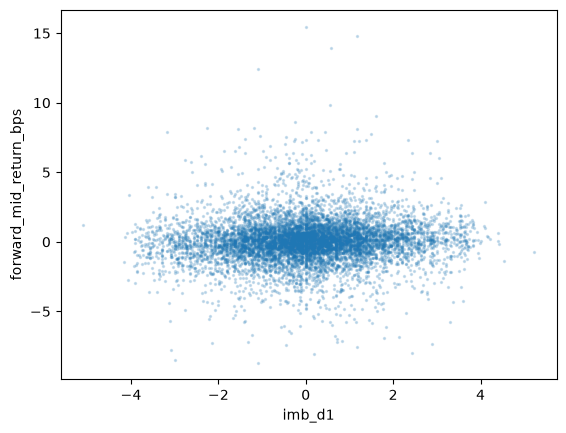

imb_d3 shape: (1, 2)
┌──────────┬────────────────────────┐
│ imb_d3   ┆ forward_mid_return_bps │
│ ---      ┆ ---                    │
│ f64      ┆ f64                    │
╞══════════╪════════════════════════╡
│ 0.047267 ┆ 1.569304               │
└──────────┴────────────────────────┘


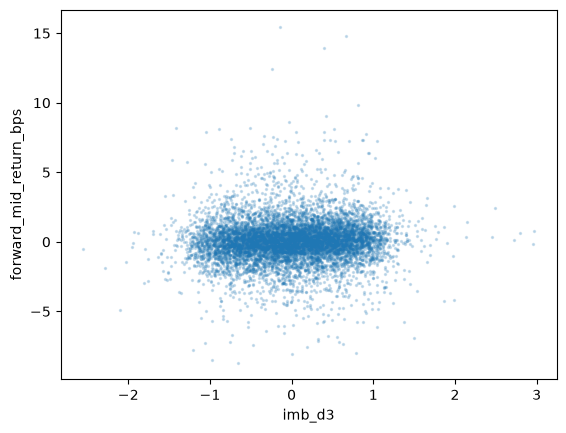

imb_d5 shape: (1, 2)
┌──────────┬────────────────────────┐
│ imb_d5   ┆ forward_mid_return_bps │
│ ---      ┆ ---                    │
│ f64      ┆ f64                    │
╞══════════╪════════════════════════╡
│ 0.047172 ┆ 1.569304               │
└──────────┴────────────────────────┘


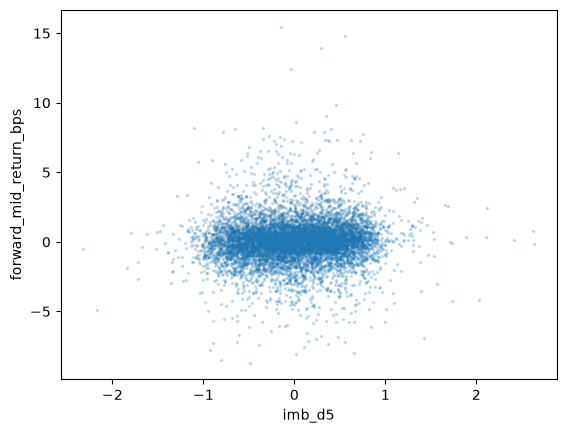

weighted_price_sz2 shape: (1, 2)
┌────────────────────┬────────────────────────┐
│ weighted_price_sz2 ┆ forward_mid_return_bps │
│ ---                ┆ ---                    │
│ f64                ┆ f64                    │
╞════════════════════╪════════════════════════╡
│ 0.042211           ┆ 1.569304               │
└────────────────────┴────────────────────────┘


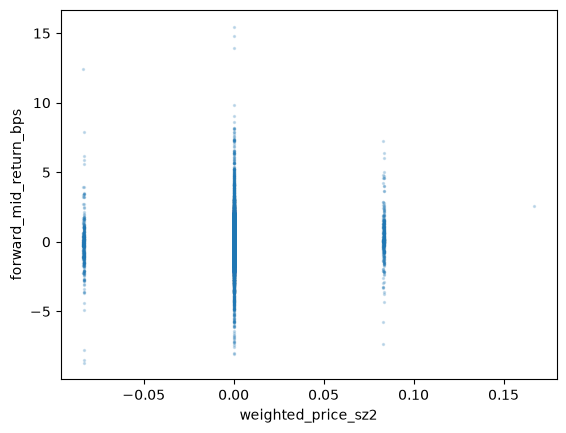

weighted_price_sz5 shape: (1, 2)
┌────────────────────┬────────────────────────┐
│ weighted_price_sz5 ┆ forward_mid_return_bps │
│ ---                ┆ ---                    │
│ f64                ┆ f64                    │
╞════════════════════╪════════════════════════╡
│ 0.05652            ┆ 1.569304               │
└────────────────────┴────────────────────────┘


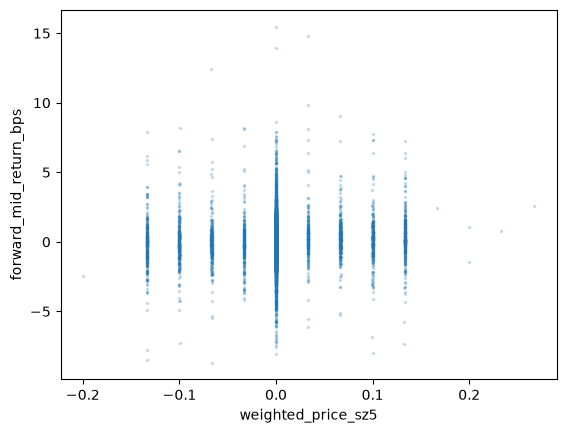

weighted_price_sz10 shape: (1, 2)
┌─────────────────────┬────────────────────────┐
│ weighted_price_sz10 ┆ forward_mid_return_bps │
│ ---                 ┆ ---                    │
│ f64                 ┆ f64                    │
╞═════════════════════╪════════════════════════╡
│ 0.056526            ┆ 1.569304               │
└─────────────────────┴────────────────────────┘


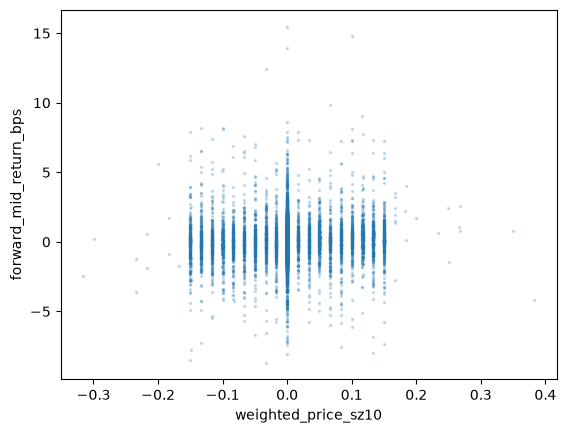

trade_momentum_hl1s shape: (1, 2)
┌─────────────────────┬────────────────────────┐
│ trade_momentum_hl1s ┆ forward_mid_return_bps │
│ ---                 ┆ ---                    │
│ f64                 ┆ f64                    │
╞═════════════════════╪════════════════════════╡
│ -0.008783           ┆ 1.569304               │
└─────────────────────┴────────────────────────┘


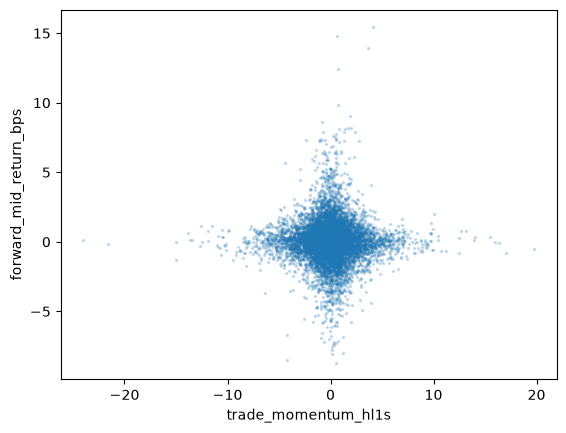

trade_momentum_hl10s shape: (1, 2)
┌──────────────────────┬────────────────────────┐
│ trade_momentum_hl10s ┆ forward_mid_return_bps │
│ ---                  ┆ ---                    │
│ f64                  ┆ f64                    │
╞══════════════════════╪════════════════════════╡
│ -0.027534            ┆ 1.569304               │
└──────────────────────┴────────────────────────┘


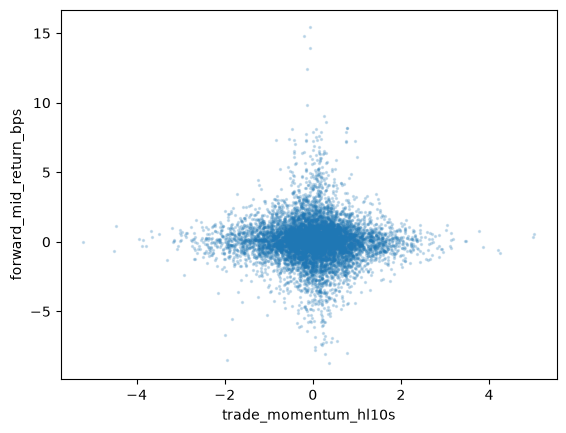

trade_momentum_hl30s shape: (1, 2)
┌──────────────────────┬────────────────────────┐
│ trade_momentum_hl30s ┆ forward_mid_return_bps │
│ ---                  ┆ ---                    │
│ f64                  ┆ f64                    │
╞══════════════════════╪════════════════════════╡
│ -0.02192             ┆ 1.569304               │
└──────────────────────┴────────────────────────┘


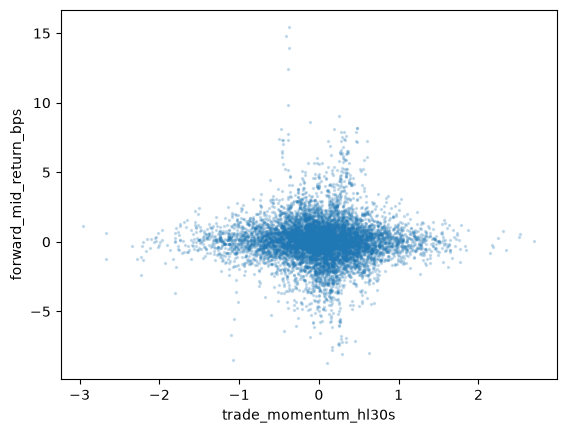

trade_momentum_hl120s shape: (1, 2)
┌───────────────────────┬────────────────────────┐
│ trade_momentum_hl120s ┆ forward_mid_return_bps │
│ ---                   ┆ ---                    │
│ f64                   ┆ f64                    │
╞═══════════════════════╪════════════════════════╡
│ -0.026249             ┆ 1.569304               │
└───────────────────────┴────────────────────────┘


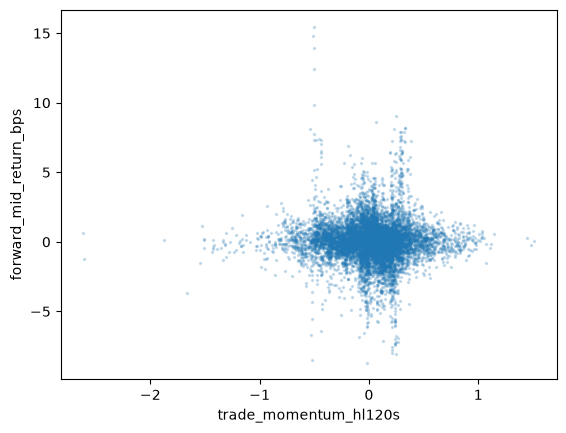

In [12]:
corr = np.zeros((len(FEATURES), len(FEATURES)))
for i, feature_i in enumerate(FEATURES):
    for j, feature_j in enumerate(FEATURES):
        corr[i, j] = df.select(pl.corr(pl.col(feature_i), pl.col(feature_j)))[0].item()
print(corr)

for feature in FEATURES:
    print(feature, df.select(pl.corr(pl.col(feature), pl.col(TARGET)), pl.col(TARGET).std()))
    plt.scatter(df[feature], df[TARGET], s=2, alpha=0.2)
    plt.xlabel(feature)
    plt.ylabel(TARGET)
    plt.show()

In [13]:
train_result = pipeline.train(verbose=2, no_refit=True)
train_result

[I 2026-07-03 23:04:50,165] A new study created in memory with name: no-name-dec97c08-47ab-4190-98bc-dab125ef3ef9


======== Optuna study created. Launching optimization.
======== running params {'eval_metric': 'quantile', 'tree_method': 'hist', 'device': 'cuda', 'seed': 7, 'max_depth': 2, 'eta': 0.1034421986607791, 'subsample': 0.7753636925763574, 'colsample_bytree': 0.8617325889154706, 'min_child_weight': 90.36058293737206, 'lambda': 0.49258292359934785, 'alpha': 0.032033347004714594}
======== fold: 0, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'] and val = ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24']


Loading data: 7.08Mrow [00:15, 447krow/s]
Loading data: 7.08Mrow [00:15, 466krow/s]
Loading data: 7.08Mrow [00:14, 480krow/s]
Loading data: 7.08Mrow [00:13, 521krow/s]
Loading data: 3.73Mrow [00:09, 396krow/s]
Loading data: 3.73Mrow [00:08, 428krow/s]
Loading data: 3.73Mrow [00:08, 432krow/s]
/home/jli/projects/rep/tools/pipeline.py:917: RuntimeWarning: XGBoost pruning requested, but optuna-integration is not installed; continuing without pruning callback.
  return self.adapter.fit(model, train, val, self.tracker, **kwargs)
Loading data: 200krow [00:00, 322krow/s]/home/jli/projects/rep/.venv/lib/python3.12/site-packages/xgboost/core.py:553: UserWarning: [23:06:28] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordina

======== loss = 0.5152007479419393, running average = 0.5152007479419393
======== fold: 1, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24'] and val = ['2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08']


Loading data: 10.8Mrow [00:21, 497krow/s]
Loading data: 10.8Mrow [00:23, 455krow/s]
Loading data: 10.8Mrow [00:23, 467krow/s]
Loading data: 10.8Mrow [00:22, 488krow/s]
Loading data: 3.13Mrow [00:09, 326krow/s]
Loading data: 3.13Mrow [00:07, 405krow/s]
Loading data: 3.13Mrow [00:07, 431krow/s]
Loading data: 3.13Mrow [00:07, 421krow/s]


...

Loading data: 13.9Mrow [00:27, 502krow/s]
Loading data: 13.9Mrow [00:29, 473krow/s]
Loading data: 13.9Mrow [00:29, 475krow/s]
Loading data: 13.9Mrow [00:28, 492krow/s]
Loading data: 4.23Mrow [00:09, 451krow/s]
Loading data: 4.23Mrow [00:09, 463krow/s]
Loading data: 4.23Mrow [00:09, 462krow/s]
Loading data: 4.23Mrow [00:08, 479krow/s]
[I 2026-07-04 00:28:35,482] Trial 18 finished with value: 0.49458440758827393 and parameters: {'eval_metric': 'quantile', 'tree_method': 'hist', 'device': 'cuda', 'seed': 7, 'max_depth': 4, 'eta': 0.10885731575606654, 'subsample': 0.9900558724628463, 'colsample_bytree': 0.6371292965972106, 'min_child_weight': 2.178723544856619, 'lambda': 24.182692353074334, 'alpha': 3.5148946995511863}. Best is trial 2 with value: 0.49417479395164066.


======== loss = 0.5301915375178168, running average = 0.49458440758827393
======== running params {'eval_metric': 'quantile', 'tree_method': 'hist', 'device': 'cuda', 'seed': 7, 'max_depth': 2, 'eta': 0.03753560664247064, 'subsample': 0.8876928566769346, 'colsample_bytree': 0.9226725793819868, 'min_child_weight': 2.170454123836959, 'lambda': 2.112733966435898, 'alpha': 1.0944030544454493}
======== fold: 0, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'] and val = ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24']


Loading data: 7.08Mrow [00:13, 541krow/s]
Loading data: 7.08Mrow [00:14, 499krow/s]
Loading data: 7.08Mrow [00:13, 522krow/s]
Loading data: 7.08Mrow [00:13, 523krow/s]
Loading data: 3.73Mrow [00:07, 469krow/s]
Loading data: 3.73Mrow [00:08, 454krow/s]
Loading data: 3.73Mrow [00:08, 447krow/s]
Loading data: 3.73Mrow [00:08, 445krow/s]
[I 2026-07-04 00:30:13,287] Trial 19 pruned. 


======== loss = 0.525111276238553, running average = 0.525111276238553
======== optimization finished, best params extracted. Skipping final refit.
======== search done.


{'best_params': {'eval_metric': 'quantile',
  'tree_method': 'hist',
  'device': 'cuda',
  'seed': 7,
  'max_depth': 3,
  'eta': 0.15254868329123253,
  'subsample': 0.6853541414319662,
  'colsample_bytree': 0.7260619809088416,
  'min_child_weight': 72.84706174508085,
  'lambda': 0.0013319751967982513,
  'alpha': 0.10063396569448359},
 'best_score': 0.49417479395164066,
 'n_trials': 20,
 'refit': False,
 'validation_history': [{'trial': 0,
   'fold': 0,
   'val_score': 0.5152007479419393,
   'weighted_score': 0.5152007479419393,
   'n': 3726630,
   'dates': ['2026-04-10',
    '2026-04-13',
    '2026-04-14',
    '2026-04-15',
    '2026-04-16',
    '2026-04-17',
    '2026-04-20',
    '2026-04-21',
    '2026-04-22',
    '2026-04-23',
    '2026-04-24'],
   'natures': ['stress', 'normal'],
   'params': {'eval_metric': 'quantile',
    'tree_method': 'hist',
    'device': 'cuda',
    'seed': 7,
    'max_depth': 2,
    'eta': 0.1034421986607791,
    'subsample': 0.7753636925763574,
    'colsamp

In [14]:
best_trial_attrs = pipeline.study.best_trial.user_attrs
xgb_fits = pl.DataFrame(best_trial_attrs.get("xgb_fits", []))
cv_rounds = [int(x) for x in best_trial_attrs.get("xgb_cv_best_num_boost_rounds", [])]
refit_num_boost_round = min(NUM_BOOST_ROUND, max(cv_rounds)) if cv_rounds else NUM_BOOST_ROUND
xgb_round_summary = {
    "median": best_trial_attrs.get("xgb_cv_best_num_boost_round_median"),
    "max": best_trial_attrs.get("xgb_cv_best_num_boost_round_max"),
    "refit": refit_num_boost_round,
    "fold_rounds": cv_rounds,
}
xgb_round_summary, xgb_fits

({'median': 100.0, 'max': 100, 'refit': 100, 'fold_rounds': [100, 100, 100]},
 shape: (3, 9)
 ┌──────┬──────┬─────────────┬─────────────┬───┬─────────────┬────────────┬────────────┬────────────┐
 │ role ┆ fold ┆ train_dates ┆ val_dates   ┆ … ┆ best_num_bo ┆ best_score ┆ num_booste ┆ history    │
 │ ---  ┆ ---  ┆ ---         ┆ ---         ┆   ┆ ost_round   ┆ ---        ┆ d_rounds   ┆ ---        │
 │ str  ┆ i64  ┆ list[str]   ┆ list[str]   ┆   ┆ ---         ┆ f64        ┆ ---        ┆ struct[2]  │
 │      ┆      ┆             ┆             ┆   ┆ i64         ┆            ┆ i64        ┆            │
 ╞══════╪══════╪═════════════╪═════════════╪═══╪═════════════╪════════════╪════════════╪════════════╡
 │ cv   ┆ 0    ┆ ["2026-03-2 ┆ ["2026-04-1 ┆ … ┆ 100         ┆ 0.510227   ┆ 100        ┆ {{[0.77045 │
 │      ┆      ┆ 3", "2026-0 ┆ 0", "2026-0 ┆   ┆             ┆            ┆            ┆ 3,         │
 │      ┆      ┆ 3-24", ……   ┆ 4-13", ……   ┆   ┆             ┆            ┆            ┆ 0.

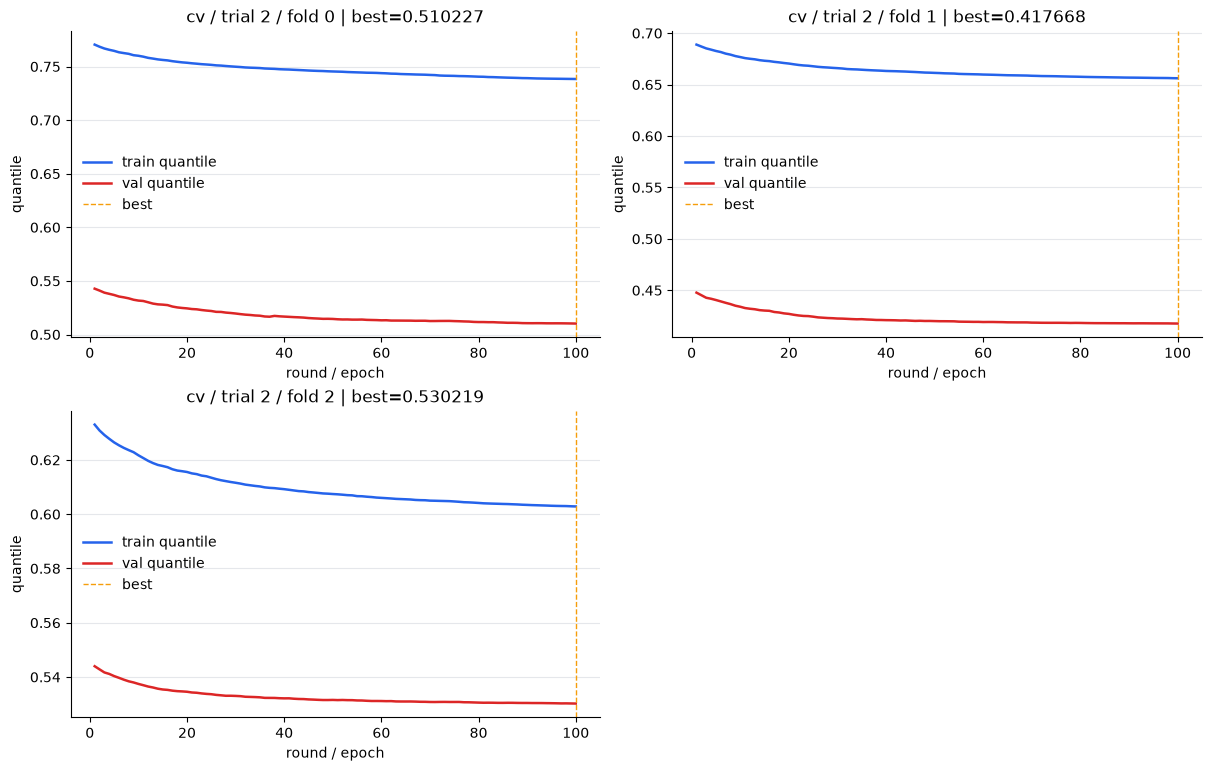

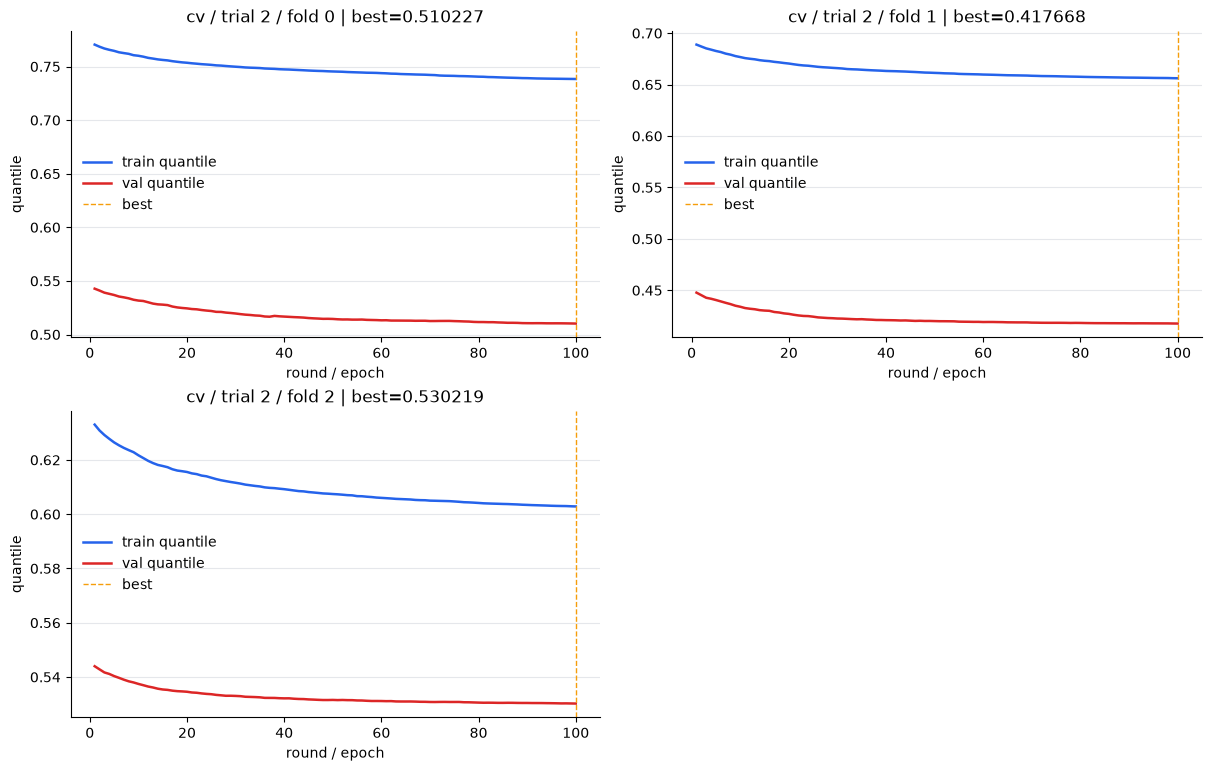

In [15]:
from tools.pipeline import plot_train_val_loss
plot_train_val_loss(train_result["validation_history"])

In [16]:
refit_num_boost_round

100

In [17]:
refit_dates = [date for dates in ROLLING_DATES for date in dates]
pipeline.adapter.num_boost_round = refit_num_boost_round
refit_result = pipeline.refit(refit_dates)
print(f"refit_num_boost_round = {refit_num_boost_round}")
pipeline.get_model()

Loading data: 18.2Mrow [00:37, 488krow/s]
Loading data: 18.2Mrow [00:39, 463krow/s]
Loading data: 18.2Mrow [00:38, 466krow/s]
Loading data: 18.2Mrow [00:36, 492krow/s]


refit_num_boost_round = 100


In [18]:
pipeline.save_pipeline('./dump/')

{'version': 2,
 'created_at': '2026-07-03T22:33:12.694608+00:00',
 'run': {'stamp': '20260703T2233', 'hash': '180683e4'},
 'target': 'forward_mid_return_bps',
 'features': ['imb_d1',
  'imb_d3',
  'imb_d5',
  'weighted_price_sz2',
  'weighted_price_sz5',
  'weighted_price_sz10',
  'trade_momentum_hl1s',
  'trade_momentum_hl10s',
  'trade_momentum_hl30s',
  'trade_momentum_hl120s'],
 'feature_registry': {},
 'rolling_dates': [['2026-03-23',
   '2026-03-24',
   '2026-03-25',
   '2026-03-26',
   '2026-03-27',
   '2026-03-30',
   '2026-03-31',
   '2026-04-01',
   '2026-04-02',
   '2026-04-06',
   '2026-04-07',
   '2026-04-08',
   '2026-04-09'],
  ['2026-04-10',
   '2026-04-13',
   '2026-04-14',
   '2026-04-15',
   '2026-04-16',
   '2026-04-17',
   '2026-04-20',
   '2026-04-21',
   '2026-04-22',
   '2026-04-23',
   '2026-04-24'],
  ['2026-04-27',
   '2026-04-28',
   '2026-04-29',
   '2026-04-30',
   '2026-05-01',
   '2026-05-04',
   '2026-05-05',
   '2026-05-06',
   '2026-05-07',
   '2026-0

In [19]:
rmse_result = pipeline.test(median_quantile(rmse))
rmse_result

Loading data: 25.6Mrow [00:18, 1.39Mrow/s]


{'test_score': 1.6033695718063485,
 'n': 25573459,
 'ctx': {'n': 25573459,
  'dates': ['2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29'],
  'natures': ['normal'],
  'fold': 'test'},
 'y_pred': array([[-2.5878894 , -0.17141487,  2.538972  ],
        [-2.539383  , -0.17141487,  2.3884368 ],
        [-2.5320976 , -0.17141487,  2.3287656 ],
        ...,
        [-3.1463046 , -0.14595509,  2.9221787 ],
        [-3.1463046 , -0.14595509,  2.9221787 ],
        [-3.1463046 , -0.14595509,  2.9221787 ]],
       shape=(25573459, 3), dtype=float32)}

In [20]:
pinball_result = pipeline.test(get_pinball(QUANTILES))

interval_src = DataSource(
    dates=TEST_DATES,
    loader=regular_loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)
y_true_test, _ = interval_src.labels()
y_pred_q = pinball_result["y_pred"]
lo, hi = y_pred_q[:, 0], y_pred_q[:, -1]
coverage = float(np.mean((y_true_test >= lo) & (y_true_test <= hi)))
width = float(np.mean(hi - lo))
target_coverage = QUANTILES[-1] - QUANTILES[0]
print(f"pinball = {pinball_result['test_score']:.6f}")
print(f"interval coverage = {coverage:.4f} (target {target_coverage:.2f})")
print(f"mean interval width = {width:.4f} bps")

Loading data: 25.6Mrow [00:09, 2.70Mrow/s]


pinball = 0.354048
interval coverage = 0.9145 (target 0.80)
mean interval width = 4.5800 bps


In [21]:
pnl_result = pipeline.test(
    get_quantile_pnl(
        q_buy=QUANTILES.index(0.1),
        q_sell=QUANTILES.index(0.9),
        thd_buy=-1.0,
        thd_sell=1.0,
    ),
    keep_predictions=False,
)
pnl_result

Loading data: 25.6Mrow [00:09, 2.79Mrow/s]


{'test_score': 0.1535201062783057,
 'n': 25573459,
 'ctx': {'n': 25573459,
  'dates': ['2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29'],
  'natures': ['normal'],
  'n_active': 492102,
  'n_buy': 231308,
  'n_sell': 260794,
  'n_overlap': 68632,
  'fold': 'test'},
 'y_pred': None}

In [22]:
pnl_threshold_result = pipeline.test(
    get_quantile_pnl(
        q_buy=QUANTILES.index(0.1),
        q_sell=QUANTILES.index(0.9),
        thd_buy=-1,
        thd_sell=1,
    ),
    keep_predictions=False,
)
pnl_threshold_result

Loading data: 25.6Mrow [00:09, 2.73Mrow/s]


{'test_score': 0.1535201062783057,
 'n': 25573459,
 'ctx': {'n': 25573459,
  'dates': ['2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29'],
  'natures': ['normal'],
  'n_active': 492102,
  'n_buy': 231308,
  'n_sell': 260794,
  'n_overlap': 68632,
  'fold': 'test'},
 'y_pred': None}

[-2.5207665   0.00406378  2.331962  ] [0.5831144  0.16161765 0.5255915 ]


Text(0, 0.5, 'count')

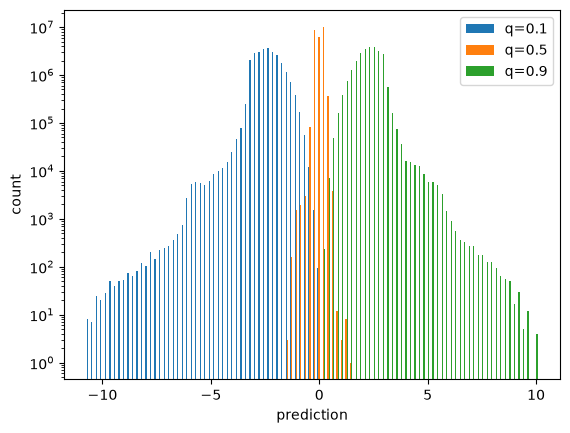

In [23]:
y_pred_q = rmse_result["y_pred"]
print(np.mean(y_pred_q, axis=0), np.std(y_pred_q, axis=0))
_ = plt.hist(y_pred_q, bins=100, log=True, density=False, label=[f"q={q}" for q in QUANTILES])
plt.legend()
plt.xlabel("prediction")
plt.ylabel("count")

In [24]:
booster = pipeline.get_model()
gain = booster.get_score(importance_type="gain")
weight = booster.get_score(importance_type="weight")

df_importance = pl.DataFrame(
    [
        {
            "feature": feature,
            "gain": float(gain.get(f"f{idx}", gain.get(feature, 0.0))),
            "weight": float(weight.get(f"f{idx}", weight.get(feature, 0.0))),
        }
        for idx, feature in enumerate(FEATURES)
    ]
).sort("gain", descending=True)

df_importance

feature,gain,weight
str,f64,f64
"""imb_d1""",518.347839,406.0
"""weighted_price_sz5""",393.399567,189.0
"""weighted_price_sz2""",301.878693,190.0
"""trade_momentum_hl1s""",276.519592,155.0
"""weighted_price_sz10""",180.303909,249.0
"""trade_momentum_hl10s""",175.60936,157.0
"""trade_momentum_hl30s""",167.797287,235.0
"""imb_d5""",163.476791,93.0
"""imb_d3""",147.315521,125.0


In [25]:
# test_src = DataSource(
#     dates=TEST_DATES,
#     loader=regular_loader,
#     target=TARGET,
#     features=FEATURES,
#     filters=(VALID_REGULAR_ROWS,),
#     polars_engine=POLARS_ENGINE,
# )
# y_true, _ = test_src.labels()
# pred_eval = pl.DataFrame({"y_true": y_true, "y_pred": pnl_threshold_result["y_pred"][:, MEDIAN_IDX]})
# n_pred = pred_eval.height
# pred_eval = pred_eval.with_columns(
#     (((pl.col("y_pred").rank("average") - 1) * 10 / n_pred).floor().clip(0, 9).cast(pl.Int8)).alias("pred_decile")
# )

# pred_eval.group_by("pred_decile").agg(
#     pl.len().alias("n"),
#     pl.col("y_pred").mean().alias("mean_pred"),
#     pl.col("y_true").mean().alias("mean_forward_return_bps"),
#     (pl.col("y_true") * pl.col("y_pred").sign()).mean().alias("mean_signed_return_bps"),
# ).sort("pred_decile")

Loading data: 25.6Mrow [00:05, 4.36Mrow/s]


Sampled 25,000 of 25,573,459 streamed test rows for SHAP.


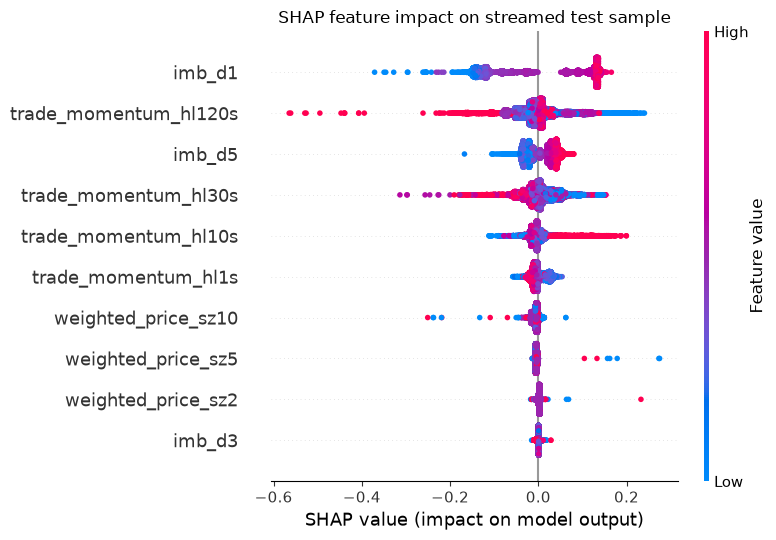

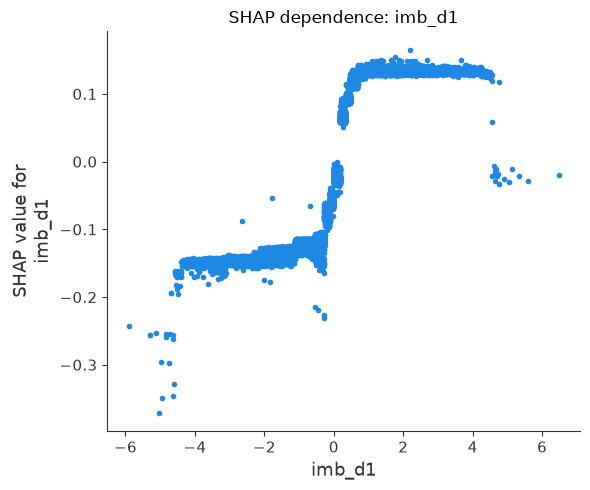

Single feature plot: imb_d1
Interaction plot: trade_momentum_hl30s x trade_momentum_hl120s on 5,000 rows


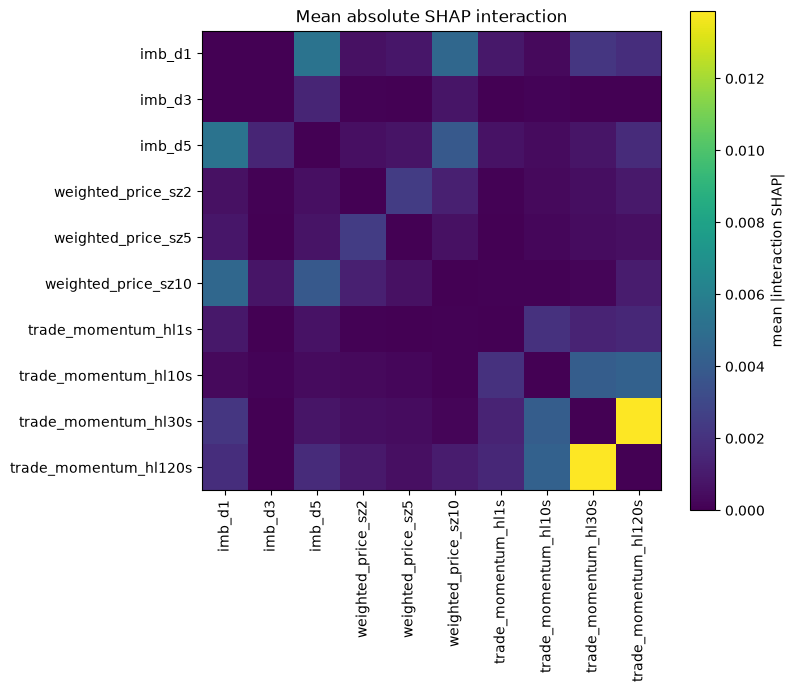

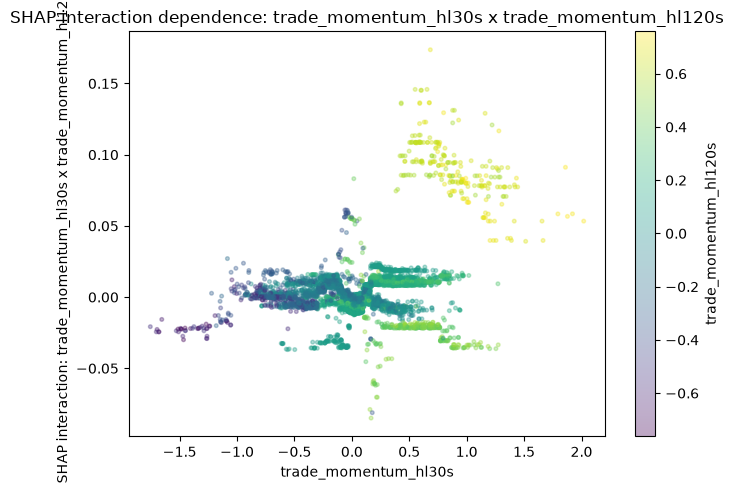

In [26]:
import pandas as pd
import shap

# Keep these bounded; the full test split is too large for SHAP interaction arrays.
SHAP_SAMPLE_ROWS = 25_000
SHAP_INTERACTION_ROWS = 5_000
SHAP_RANDOM_SEED = SEED
SHAP_BATCH_SIZE = MODEL_BATCH_SIZE
SHAP_SINGLE_FEATURE = None  # e.g. "imb_d5"; None chooses highest mean |SHAP|.
SHAP_INTERACTION_PAIR = None  # e.g. ("imb_d5", "imb_d3"); None chooses strongest pair.


def sample_stream_rows(src, max_rows: int, batch_size: int, seed: int):
    total_rows = src.count()
    sample_rows = min(int(max_rows), total_rows)
    if sample_rows <= 0:
        raise ValueError("cannot build SHAP sample from an empty test source")

    rng = np.random.default_rng(seed)
    sample_pos = np.sort(rng.choice(total_rows, size=sample_rows, replace=False))
    x_parts = []
    y_parts = []
    offset = 0
    cursor = 0

    for x, y, _ in src.batches(batch_size):
        n = len(y)
        end = offset + n
        next_cursor = np.searchsorted(sample_pos, end, side="left")
        if next_cursor > cursor:
            local_pos = sample_pos[cursor:next_cursor] - offset
            x_parts.append(np.asarray(x[local_pos], dtype=np.float32))
            y_parts.append(np.asarray(y[local_pos]))
        offset = end
        cursor = next_cursor
        if cursor >= sample_rows:
            break

    if not x_parts:
        raise ValueError("SHAP sampler did not collect any rows")
    return np.vstack(x_parts), np.concatenate(y_parts), total_rows


shap_test_src = DataSource(
    dates=TEST_DATES,
    loader=regular_loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)

X_shap, y_shap, shap_total_rows = sample_stream_rows(
    shap_test_src,
    max_rows=SHAP_SAMPLE_ROWS,
    batch_size=SHAP_BATCH_SIZE,
    seed=SHAP_RANDOM_SEED,
)
X_shap_df = pd.DataFrame(X_shap, columns=FEATURES)
print(f"Sampled {len(X_shap_df):,} of {shap_total_rows:,} streamed test rows for SHAP.")

booster = pipeline.get_model()
shap_explainer = shap.TreeExplainer(booster)
shap_values = shap_explainer.shap_values(X_shap_df)
if isinstance(shap_values, list):
    shap_values = shap_values[MEDIAN_IDX]
shap_values = np.asarray(shap_values)
if shap_values.ndim == 3:
    # Multi-quantile booster: (n, features, quantiles); explain the median output.
    shap_values = shap_values[..., MEDIAN_IDX]

mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_order = np.argsort(mean_abs_shap)[::-1]
single_feature = SHAP_SINGLE_FEATURE or FEATURES[int(feature_order[0])]
if single_feature not in FEATURES:
    raise ValueError(f"unknown SHAP_SINGLE_FEATURE {single_feature!r}")

shap.summary_plot(shap_values, X_shap_df, max_display=len(FEATURES), show=False)
plt.title("SHAP feature impact on streamed test sample")
plt.tight_layout()
plt.show()

shap.dependence_plot(
    single_feature,
    shap_values,
    X_shap_df,
    interaction_index=None,
    show=False,
)
plt.title(f"SHAP dependence: {single_feature}")
plt.tight_layout()
plt.show()

interaction_rows = min(int(SHAP_INTERACTION_ROWS), len(X_shap_df))
X_interaction_df = X_shap_df.iloc[:interaction_rows].copy()
shap_interaction_values = shap_explainer.shap_interaction_values(X_interaction_df)
if isinstance(shap_interaction_values, list):
    shap_interaction_values = shap_interaction_values[MEDIAN_IDX]
shap_interaction_values = np.asarray(shap_interaction_values)
if shap_interaction_values.ndim == 4:
    shap_interaction_values = shap_interaction_values[..., MEDIAN_IDX]
if shap_interaction_values.shape[1:] != (len(FEATURES), len(FEATURES)):
    raise ValueError(
        "unexpected SHAP interaction shape "
        f"{shap_interaction_values.shape}; expected (*, {len(FEATURES)}, {len(FEATURES)})"
    )

mean_abs_interaction = np.abs(shap_interaction_values).mean(axis=0)
mean_abs_interaction_no_diag = mean_abs_interaction.copy()
np.fill_diagonal(mean_abs_interaction_no_diag, 0.0)

if SHAP_INTERACTION_PAIR is None:
    i, j = np.unravel_index(
        int(np.argmax(mean_abs_interaction_no_diag)),
        mean_abs_interaction_no_diag.shape,
    )
    interaction_pair = (FEATURES[int(i)], FEATURES[int(j)])
else:
    interaction_pair = tuple(SHAP_INTERACTION_PAIR)
    if len(interaction_pair) != 2 or any(feature not in FEATURES for feature in interaction_pair):
        raise ValueError(f"unknown SHAP_INTERACTION_PAIR {SHAP_INTERACTION_PAIR!r}")
    i, j = (FEATURES.index(interaction_pair[0]), FEATURES.index(interaction_pair[1]))

print(f"Single feature plot: {single_feature}")
print(f"Interaction plot: {interaction_pair[0]} x {interaction_pair[1]} on {interaction_rows:,} rows")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(mean_abs_interaction_no_diag, cmap="viridis")
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=90)
ax.set_yticks(range(len(FEATURES)), FEATURES)
ax.set_title("Mean absolute SHAP interaction")
fig.colorbar(im, ax=ax, label="mean |interaction SHAP|")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    X_interaction_df[interaction_pair[0]],
    shap_interaction_values[:, i, j],
    c=X_interaction_df[interaction_pair[1]],
    s=7,
    alpha=0.35,
    cmap="viridis",
)
ax.set_xlabel(interaction_pair[0])
ax.set_ylabel(f"SHAP interaction: {interaction_pair[0]} x {interaction_pair[1]}")
ax.set_title(f"SHAP interaction dependence: {interaction_pair[0]} x {interaction_pair[1]}")
fig.colorbar(scatter, ax=ax, label=interaction_pair[1])
fig.tight_layout()
plt.show()